In [2]:
import os

os.listdir("../data/processed")

['uk_energy_master.csv', 'uk_energy_master.parquet']

In [3]:
import pandas as pd

# Load master dataset
df = pd.read_parquet(
    "../data/processed/uk_energy_master.parquet"
)

# Fix mixed date formats
df["SETTLEMENT_DATE"] = pd.to_datetime(
    df["SETTLEMENT_DATE"],
    format="mixed",
    dayfirst=True
)

# Create daily dataset
daily_df = (
    df.groupby("SETTLEMENT_DATE")["ND"]
      .mean()
      .reset_index()
)

print(daily_df.shape)

daily_df.head()

(9264, 2)


,SETTLEMENT_DATE,ND
0,2001-01-01,35616.520833
1,2001-01-02,47423.416667
2,2001-01-03,47082.916667
3,2001-01-04,34527.708333
4,2001-01-05,39791.687500


In [4]:
daily_df.to_parquet(
    "../data/processed/daily_energy.parquet",
    index=False
)

print("daily_energy.parquet saved successfully")

daily_energy.parquet saved successfully


In [5]:
import os

os.listdir("../data/processed")

['daily_energy.parquet', 'uk_energy_master.csv', 'uk_energy_master.parquet']

In [6]:
daily_df = pd.read_parquet(
    "../data/processed/daily_energy.parquet"
)

print(daily_df.shape)

(9264, 2)


In [7]:
daily_df = daily_df.sort_values(
    "SETTLEMENT_DATE"
)

daily_df.reset_index(
    drop=True,
    inplace=True
)

daily_df.head()

,SETTLEMENT_DATE,ND
0,2001-01-01,35616.520833
1,2001-01-02,47423.416667
2,2001-01-03,47082.916667
3,2001-01-04,34527.708333
4,2001-01-05,39791.687500


In [8]:
daily_df["lag_1"] = daily_df["ND"].shift(1)

daily_df["lag_7"] = daily_df["ND"].shift(7)

daily_df["lag_30"] = daily_df["ND"].shift(30)

In [9]:
daily_df["rolling_mean_7"] = (
    daily_df["ND"]
    .rolling(7)
    .mean()
)

daily_df["rolling_mean_30"] = (
    daily_df["ND"]
    .rolling(30)
    .mean()
)

In [10]:
daily_df["rolling_std_7"] = (
    daily_df["ND"]
    .rolling(7)
    .std()
)

daily_df["rolling_std_30"] = (
    daily_df["ND"]
    .rolling(30)
    .std()
)

In [11]:
daily_df["year"] = (
    daily_df["SETTLEMENT_DATE"]
    .dt.year
)

daily_df["month"] = (
    daily_df["SETTLEMENT_DATE"]
    .dt.month
)

daily_df["quarter"] = (
    daily_df["SETTLEMENT_DATE"]
    .dt.quarter
)

daily_df["day_of_week"] = (
    daily_df["SETTLEMENT_DATE"]
    .dt.dayofweek
)

daily_df["day_of_year"] = (
    daily_df["SETTLEMENT_DATE"]
    .dt.dayofyear
)

In [12]:
daily_df["is_weekend"] = (
    daily_df["day_of_week"] >= 5
).astype(int)

In [13]:
daily_df["is_month_start"] = (
    daily_df["SETTLEMENT_DATE"]
    .dt.is_month_start
).astype(int)

daily_df["is_month_end"] = (
    daily_df["SETTLEMENT_DATE"]
    .dt.is_month_end
).astype(int)

In [14]:
daily_df.head()

,SETTLEMENT_DATE,ND,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,year,month,quarter,day_of_week,day_of_year,is_weekend,is_month_start,is_month_end
0,2001-01-01,35616.520833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2001,1,1,0,1,0,1,0
1,2001-01-02,47423.416667,35616.520833,NaN,NaN,NaN,NaN,NaN,NaN,2001,1,1,1,2,0,0,0
2,2001-01-03,47082.916667,47423.416667,NaN,NaN,NaN,NaN,NaN,NaN,2001,1,1,2,3,0,0,0
3,2001-01-04,34527.708333,47082.916667,NaN,NaN,NaN,NaN,NaN,NaN,2001,1,1,3,4,0,0,0
4,2001-01-05,39791.687500,34527.708333,NaN,NaN,NaN,NaN,NaN,NaN,2001,1,1,4,5,0,0,0


In [15]:
daily_df.isnull().sum()

SETTLEMENT_DATE     0
ND                  0
lag_1               1
lag_7               7
lag_30             30
rolling_mean_7      6
rolling_mean_30    29
rolling_std_7       6
rolling_std_30     29
year                0
month               0
quarter             0
day_of_week         0
day_of_year         0
is_weekend          0
is_month_start      0
is_month_end        0
dtype: int64

In [16]:
daily_df = daily_df.dropna()

print(daily_df.shape)

(9234, 17)


In [17]:
corr = daily_df.corr(
    numeric_only=True
)

corr["ND"].sort_values(
    ascending=False
)

ND                 1.000000
rolling_mean_7     0.888172
lag_1              0.884705
rolling_mean_30    0.856894
lag_7              0.802994
lag_30             0.744527
rolling_std_30     0.554034
rolling_std_7      0.381446
is_month_start     0.047795
is_month_end      -0.009304
month             -0.085744
day_of_year       -0.087300
quarter           -0.088777
day_of_week       -0.203895
is_weekend        -0.253012
year              -0.693768
Name: ND, dtype: float64

In [18]:
daily_df.to_parquet(
    "../data/processed/energy_features.parquet",
    index=False
)

print("Feature dataset saved")

Feature dataset saved


In [19]:
import os

os.listdir("../data/processed")

['daily_energy.parquet',
 'energy_features.parquet',
 'uk_energy_master.csv',
 'uk_energy_master.parquet']

In [20]:
daily_df.shape

(9234, 17)

In [21]:
corr["ND"].sort_values(ascending=False)

ND                 1.000000
rolling_mean_7     0.888172
lag_1              0.884705
rolling_mean_30    0.856894
lag_7              0.802994
lag_30             0.744527
rolling_std_30     0.554034
rolling_std_7      0.381446
is_month_start     0.047795
is_month_end      -0.009304
month             -0.085744
day_of_year       -0.087300
quarter           -0.088777
day_of_week       -0.203895
is_weekend        -0.253012
year              -0.693768
Name: ND, dtype: float64

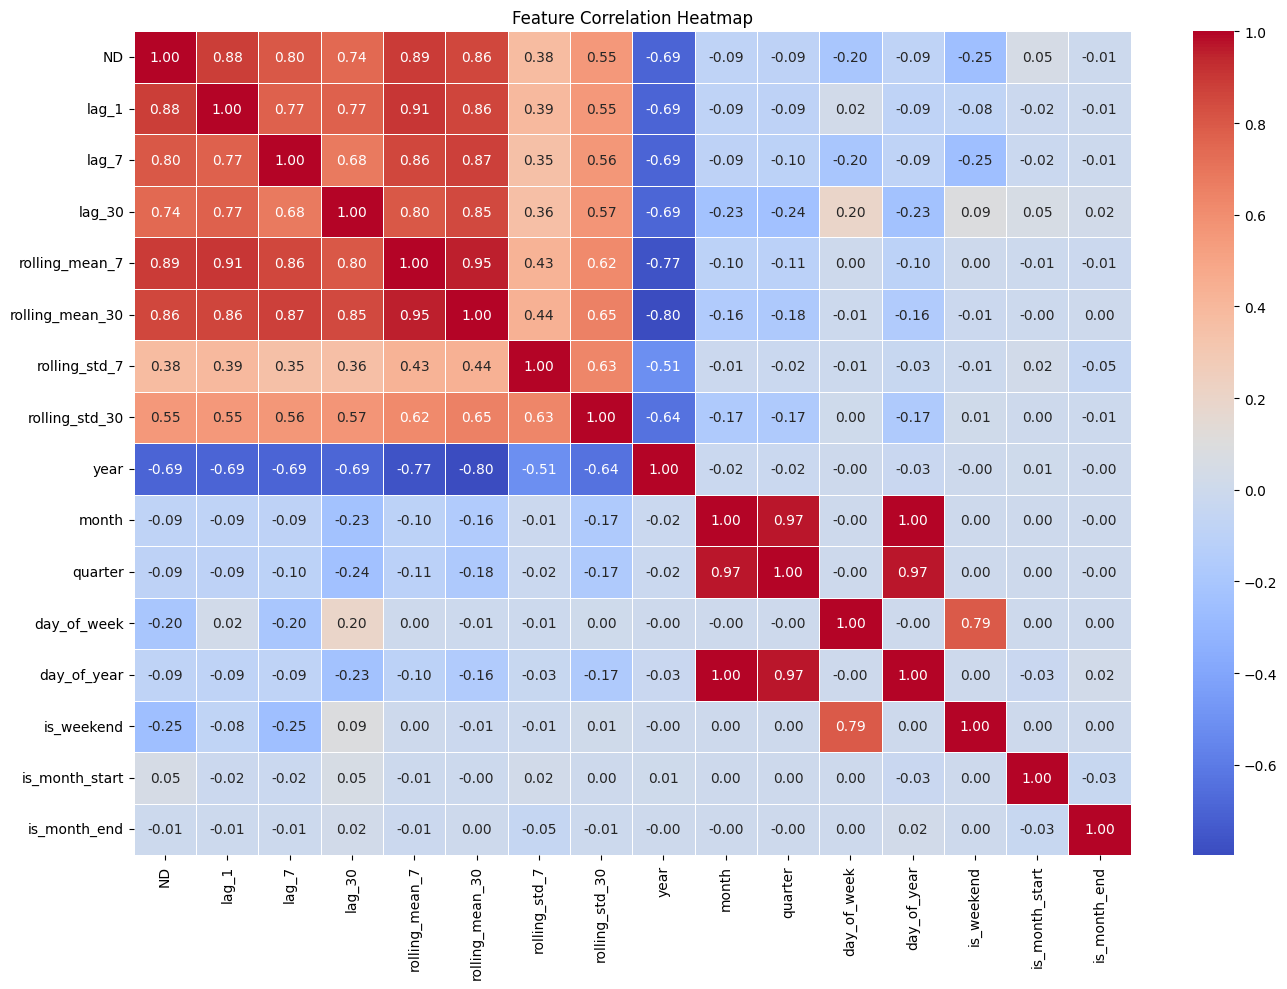

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

corr_matrix = daily_df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.tight_layout()
plt.savefig(
    "../reports/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

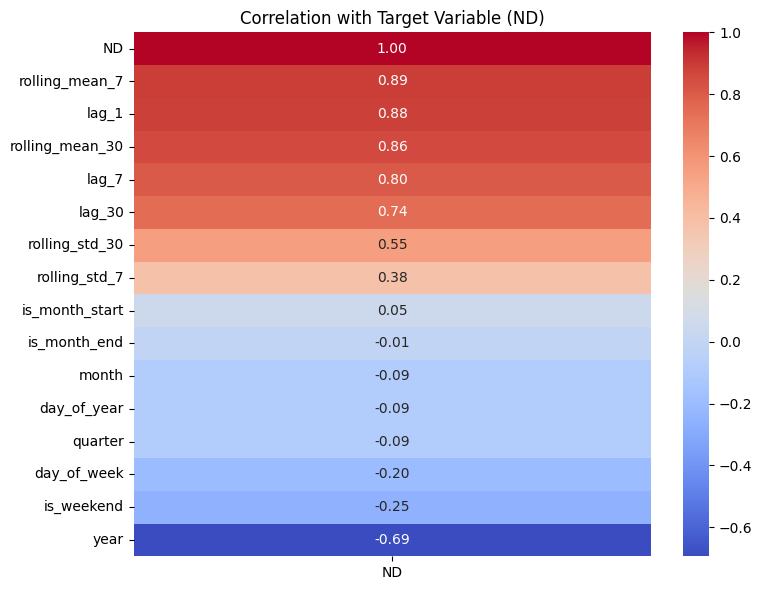

In [24]:
plt.figure(figsize=(8,6))

target_corr = (
    daily_df.corr(numeric_only=True)[["ND"]]
    .sort_values(
        by="ND",
        ascending=False
    )
)

sns.heatmap(
    target_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation with Target Variable (ND)"
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/target_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
target_corr

,ND
ND,1.000000
rolling_mean_7,0.888172
lag_1,0.884705
rolling_mean_30,0.856894
lag_7,0.802994
lag_30,0.744527
rolling_std_30,0.554034
rolling_std_7,0.381446
is_month_start,0.047795
is_month_end,-0.009304
